(15, 1101, 118, 118)


Computing Dynamic Correlation - CLIP-HBA-Dynamic: 100%|██████████| 1101/1101 [00:01<00:00, 664.69it/s]


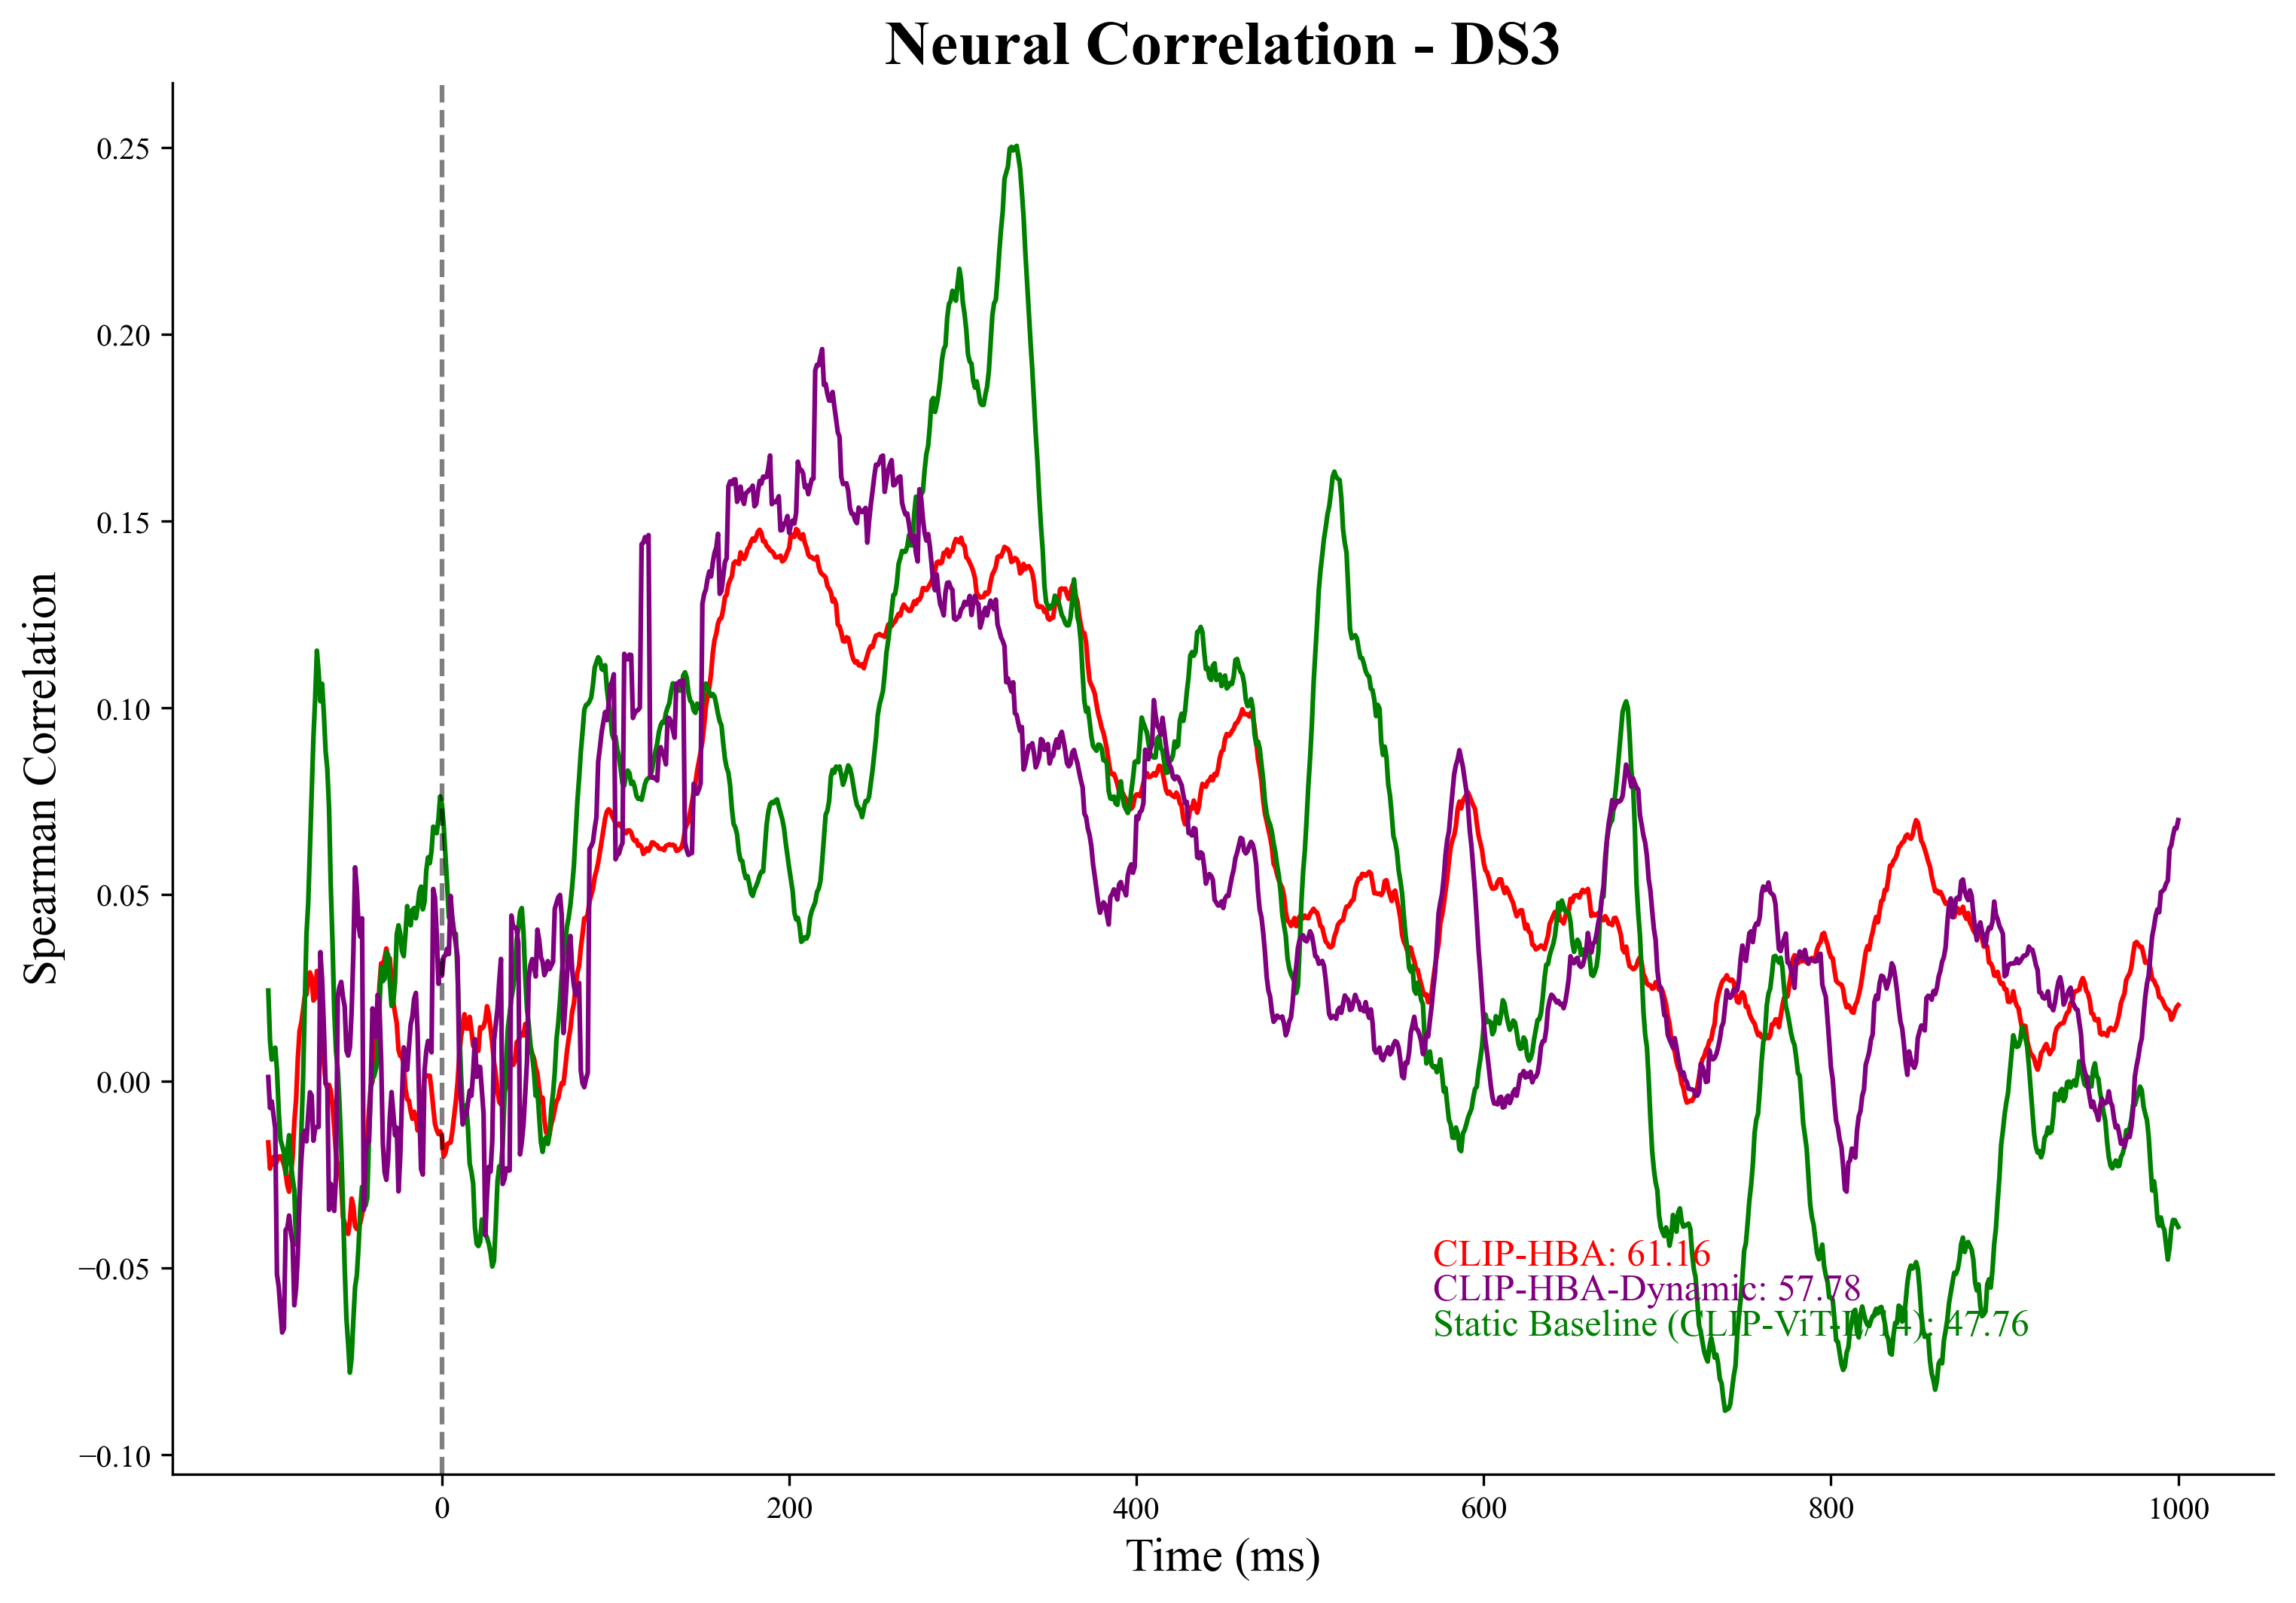

In [5]:
import os
import h5py
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm
from numpy import trapz
from scipy.io import loadmat
from scipy.special import softmax
from tqdm import tqdm
import pandas as pd
plt.rcParams['font.family'] = 'Times New Roman'  # Set font to Times New Roman

def load_dynamic_rdms(dynamic_rdm_dir):
    rdms = np.load(dynamic_rdm_dir)
    return rdms

def process_neural_rdms(path):
    if path.endswith('.mat'):
        try:
            mat = loadmat(path)['result_dsm']
            neural_rdms = np.transpose(mat, (0, 3, 1, 2))
        except NotImplementedError:
            with h5py.File(path, 'r') as f:
                mat = f['result_dsm'][:]
                neural_rdms = np.transpose(mat, (3, 0, 1, 2))
    elif path.endswith('.npy'):
        neural_rdms = np.load(path)
    print(neural_rdms.shape)

        
    average_neural_rdms = np.mean(neural_rdms, axis=0)

    return neural_rdms, average_neural_rdms

def find_neural_index(ms_timepoint):
    return neural_timepoints_list.index(ms_timepoint)

def ms_to_model_index(ms_timepoint, ms_start, ms_step):
    return (ms_timepoint - ms_start) // ms_step

def calculate_model_correlation(model_rdm, neural_rdms, model_desc = "CLIP-HBA"):
    model_correlations = []
    indices = np.triu_indices_from(model_rdm, k=1)
    model_rdm_flat = model_rdm[indices]
    for time_point in tqdm(range(neural_rdms.shape[0]), desc=f"Computing Static Correlation - {model_desc}"):
        neural_rdm_flat = neural_rdms[time_point][indices]
        corr, _ = spearmanr(model_rdm_flat, neural_rdm_flat, nan_policy='omit')
        model_correlations.append(corr)
    return model_correlations


def compute_dynamic_model_correlation(model_rdms, neural_rdms, model_desc = "CLIP-HBA-Dynamic"):
    assert model_rdms.shape[1:] == neural_rdms.shape[1:], "Model and neural RDMs must have the same shape"
    dynamic_correlations = []
    for neural_timepoint in tqdm(neural_timepoints_list, desc = f"Computing Dynamic Correlation - {model_desc}"):
        neural_rdm_index = find_neural_index(neural_timepoint)
        neural_rdm = neural_rdms[neural_rdm_index]
        if neural_timepoint <= model_ms_start:
            model_rdm = model_rdms[0]
            model_rdm_flat = model_rdm[np.triu_indices_from(model_rdm, k=1)]
            neural_rdm_flat = neural_rdm[np.triu_indices_from(neural_rdm, k=1)]
            corr, _ = spearmanr(model_rdm_flat, neural_rdm_flat, nan_policy='omit')
            dynamic_correlations.append(corr)
        elif neural_timepoint >= model_ms_end:
            model_rdm = model_rdms[-1]
            model_rdm_flat = model_rdm[np.triu_indices_from(model_rdm, k=1)]
            neural_rdm_flat = neural_rdm[np.triu_indices_from(neural_rdm, k=1)]
            corr, _ = spearmanr(model_rdm_flat, neural_rdm_flat, nan_policy='omit')
            dynamic_correlations.append(corr)
        else:    
            model_rdm = model_rdms[ms_to_model_index(neural_timepoint, model_ms_start, model_ms_step)]
            model_rdm_flat = model_rdm[np.triu_indices_from(model_rdm, k=1)]
            neural_rdm_flat = neural_rdm[np.triu_indices_from(neural_rdm, k=1)]
            corr, _ = spearmanr(model_rdm_flat, neural_rdm_flat, nan_policy='omit')
            dynamic_correlations.append(corr)

            
        
    return dynamic_correlations

if __name__ == '__main__':

    ############################################################################################################
    # Neural RDMs
    neural_rdm_path = "../Data/Cichy/Cichy_MEG_RDM_rescaled.npy"

    # Static RDMs
    hba_rdm_path = "../../output/cliphba/cichy/rdm/static_rdm.hdf5"
    baseline_static_rdm_path = '../../output/baseline_static_vit/cichy/rdm/static_rdm.hdf5'

    # dynamic RDM Folders
    hba_dynamic_rdm_dir = '../../output/cliphba_dynamic_3d_v12/cichy/rdms_-100ms-1300ms-5step.npy'


    # Neural Data Timepoints Info
    neural_ms_start = -100 # first timepoint in ms for neural data
    neural_ms_end = 1000 # last timepoint in ms for neural data
    neural_ms_step = 1 # every _ ms 
    neural_timepoints_list = list(range(neural_ms_start, neural_ms_end + 1, neural_ms_step))

    # Dynamic Model Timepoints Info
    model_ms_start = -100
    model_ms_end = 1300
    model_ms_step = 5
    model_timepoints_list = list(range(model_ms_start, model_ms_end + 1, model_ms_step))

    # Parameters
    auc_cutoff_ms = 0
    ann_x = 0.60
    ann_y = 0.15
    ann_delta_y = 0.025
    plot_title = "Neural Correlation - DS3"
    title_fontsize = 20
    ############################################################################################################


    # Load Neural RDMs
    neural_rdms, average_neural_rdms = process_neural_rdms(neural_rdm_path)

    # Load Static CLIP-HBA RDM
    with h5py.File(hba_rdm_path, 'r') as f:
        hba_rdm = f['rdm'][:]

    #Load Static Baseline CLIP-ViT RDM
    with h5py.File(baseline_static_rdm_path, 'r') as f:
        baseline_rdm = f['rdm'][:]


    hba_dynamic_rdms = load_dynamic_rdms(hba_dynamic_rdm_dir)


    # Calculate correlations
    hba_static_correlation = calculate_model_correlation(hba_rdm, average_neural_rdms, model_desc="CLIP-HBA")
    baseline_static_correlation = calculate_model_correlation(baseline_rdm, average_neural_rdms, model_desc="Baseline")
    hba_dynamic_correlations = compute_dynamic_model_correlation(hba_dynamic_rdms, average_neural_rdms, model_desc="CLIP-HBA-Dynamic")


    auc_start_index = ms_to_model_index(auc_cutoff_ms, model_ms_start, model_ms_step)

    auc_hba_static = trapz(hba_static_correlation[auc_start_index:], dx=np.diff(neural_timepoints_list)[0])
    auc_baseline_static = trapz(baseline_static_correlation[auc_start_index:], dx=np.diff(neural_timepoints_list)[0])
    auc_hba_dynamic = trapz(hba_dynamic_correlations[auc_start_index:], dx=np.diff(neural_timepoints_list)[0])


    
    '''-----------------------------------------------------------------------------------------------------------------'''
    
    # Plotting
    plt.figure(figsize=(12, 8), dpi=300)  # Set resolution
    plt.rcParams['font.family'] = 'Times New Roman'  # Set font to Times New Roman
    plt.plot(neural_timepoints_list, hba_static_correlation, label='CLIP-HBA Static Correlation', color='red')
    plt.plot(neural_timepoints_list, baseline_static_correlation, label='Baseline Correlation', color='green')
    plt.plot(neural_timepoints_list, hba_dynamic_correlations, label='CLIP-HBA-Dynamic Correlation', color='purple')
    plt.axvline(x=auc_cutoff_ms, color='black', linestyle='--', label='AUC Cutoff', alpha=0.5)

    # Display Sorted AUC 
    auc_array_dict = {'CLIP-HBA': [auc_hba_static, "red"], 'Static Baseline (CLIP-ViT-L/14)': [auc_baseline_static, "green"], 'CLIP-HBA-Dynamic': [auc_hba_dynamic, "purple"]}
    auc_array_dict_sorted = {k: v for k, v in sorted(auc_array_dict.items(), key=lambda item: item[1], reverse=True)}


    for i in range(len(auc_array_dict_sorted)):
        plt.text(ann_x, ann_y, f"{list(auc_array_dict_sorted.keys())[i]}: {list(auc_array_dict_sorted.values())[i][0]:.2f}", color=list(auc_array_dict_sorted.values())[i][1], fontsize=12, transform=plt.gca().transAxes)
        ann_y -= ann_delta_y


    # Remove top and right frame
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.xlabel('Time (ms)', fontsize=15)
    plt.ylabel("Spearman Correlation", fontsize=15)
    plt.title(plot_title, fontsize=title_fontsize, fontweight='bold')
    plt.show

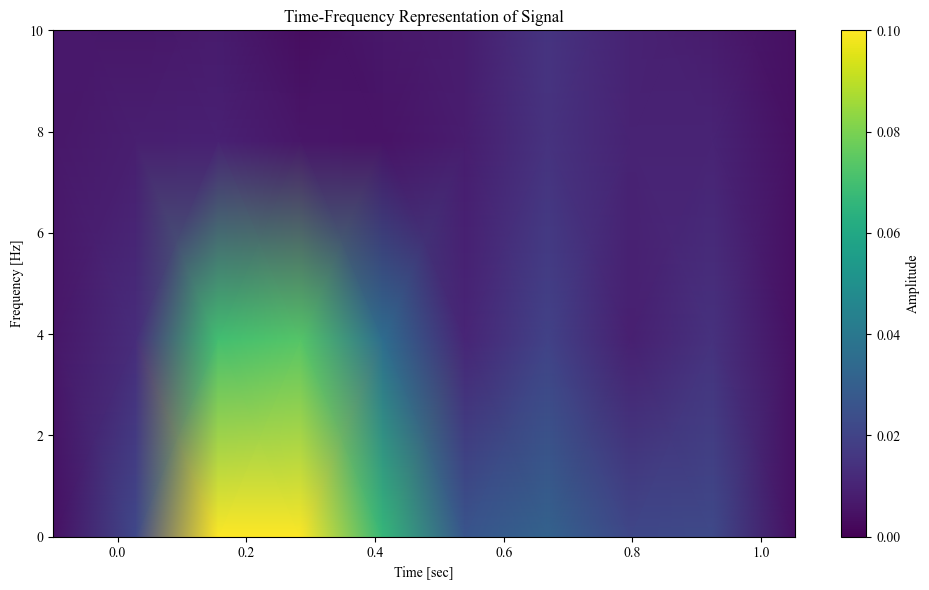

In [2]:
from scipy import signal

alignment_vector = np.array(hba_dynamic_correlations)
fs = 1000


# Compute the Short-Time Fourier Transform (STFT)
frequencies, times, Zxx = signal.stft(alignment_vector, fs, nperseg=256)
times = times + (-0.1)

# Plot the time-frequency representation
plt.figure(figsize=(10, 6))
plt.pcolormesh(times, frequencies, np.abs(Zxx), shading='gouraud', vmin=0, vmax=0.1)
plt.title('Time-Frequency Representation of Signal')
plt.ylim([0, 10])  # Focus on the frequencies from 0 to 10 Hz
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Amplitude')
plt.tight_layout()
plt.show()

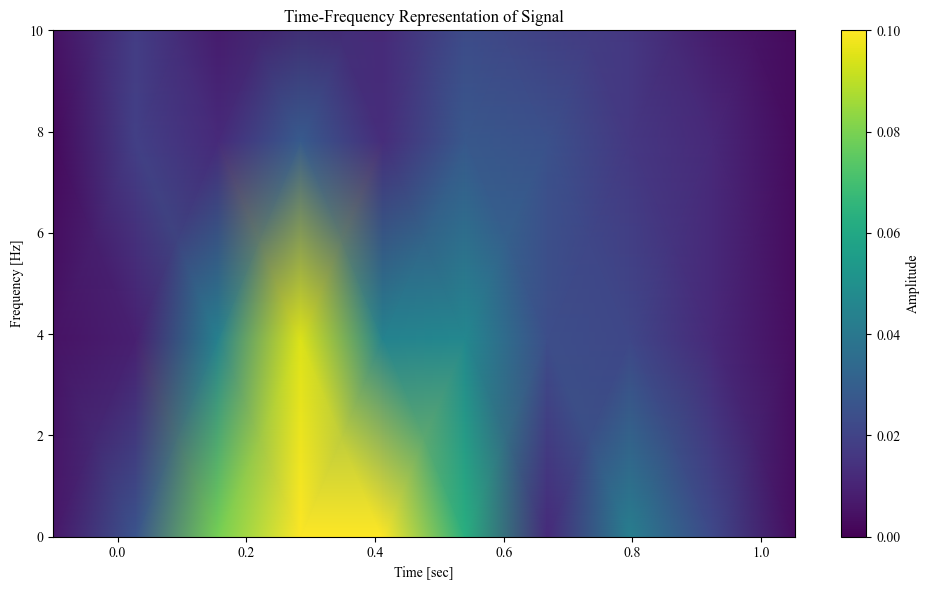

In [3]:
from scipy import signal

alignment_vector = np.array(baseline_static_correlation)
fs = 1000


# Compute the Short-Time Fourier Transform (STFT)
frequencies, times, Zxx = signal.stft(alignment_vector, fs, nperseg=256)
times = times + (-0.1)

# Plot the time-frequency representation
plt.figure(figsize=(10, 6))
plt.pcolormesh(times, frequencies, np.abs(Zxx), shading='gouraud', vmin=0, vmax=0.1)
plt.title('Time-Frequency Representation of Signal')
plt.ylim([0, 10])  # Focus on the frequencies from 0 to 10 Hz
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Amplitude')
plt.tight_layout()
plt.show()

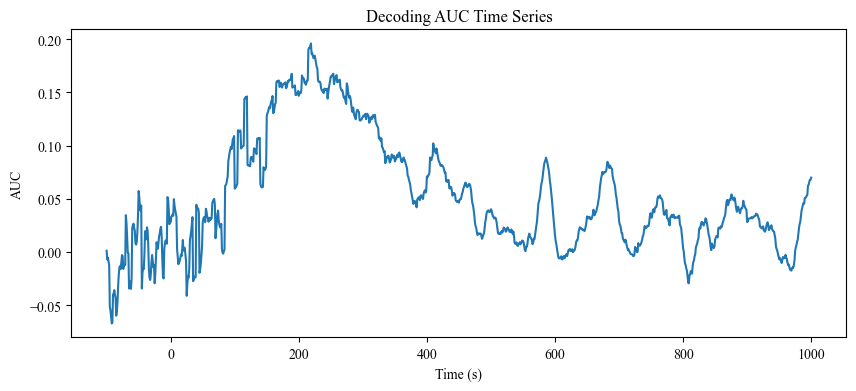

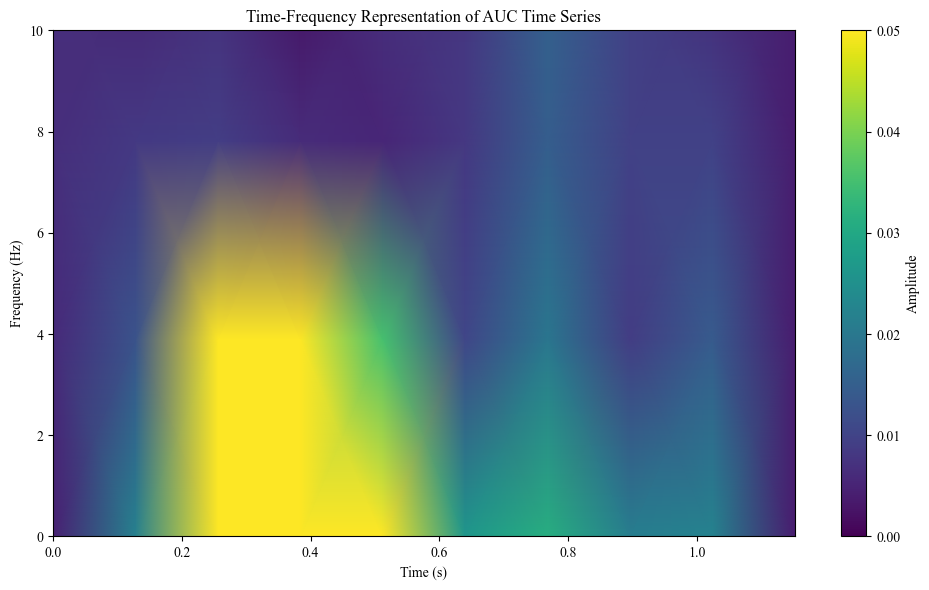

Mean AUC: 0.0518
High-Frequency Energy: 0.0031
Penalized AUC: 0.0515


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
# Generate synthetic AUC time series
np.random.seed(42)
time = np.linspace(-100, 1000, 1101)  # 10 seconds, 1000 points
# Simulate stable AUC with added high-frequency noise
auc_time_series = hba_dynamic_correlations
# Plot AUC time series
plt.figure(figsize=(10, 4))
plt.plot(time, auc_time_series)
plt.title('Decoding AUC Time Series')
plt.xlabel('Time (s)')
plt.ylabel('AUC')
plt.show()
# Apply STFT to the AUC time series
fs = 1000  # Sampling frequency (assuming 100 Hz)
frequencies, times, Zxx = signal.stft(auc_time_series, fs, nperseg=256)
# Plot the spectrogram
plt.figure(figsize=(10, 6))
plt.pcolormesh(times, frequencies, np.abs(Zxx), shading='gouraud', vmin=0, vmax=0.05)
plt.title('Time-Frequency Representation of AUC Time Series')
plt.ylim([0, 10])  # Focus on the frequencies from 0 to 10 Hz
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.colorbar(label='Amplitude')
plt.tight_layout()
plt.show()
# Define high-frequency threshold (e.g., above 5 Hz)
high_freq_threshold = 5  # Hz
high_freq_indices = frequencies > high_freq_threshold
# Calculate total high-frequency energy
high_freq_energy = np.sum(np.abs(Zxx[high_freq_indices, :])**2)
# Compute mean AUC
mean_auc = np.mean(auc_time_series)
# Define penalized AUC
lambda_penalty = 0.1  # Penalty weight (adjust as needed)
penalized_auc = mean_auc - lambda_penalty * high_freq_energy
print(f"Mean AUC: {mean_auc:.4f}")
print(f"High-Frequency Energy: {high_freq_energy:.4f}")
print(f"Penalized AUC: {penalized_auc:.4f}")